***1. Conducting the Analysis***

**1.1 Importing Required Libraries**

The required Python libraries are imported before conducting the analysis. NumPy and Pandas are used for numerical and tabular data processing, while Matplotlib is used for data visualisation.

PySpark is used to load, clean and explore the dataset in accordance with the portfolio requirement to use Spark. Scikit-learn is used for splitting the data, encoding the target variable and calculating classification metrics.

TensorFlow and Keras are used to construct and train the recurrent neural network. A random seed is also specified to improve the reproducibility of the model results.

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    count,
    when,
    length,
    trim,
    desc,
    split,
    size,
    avg
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


**2.2 Initialising Apache Spark**

A SparkSession is created to provide access to Spark functionality within the Jupyter Notebook.

Spark will be used for the initial stages of the analysis, including loading the dataset, examining its structure, identifying missing and duplicate records, cleaning the data and conducting exploratory data analysis.

The Spark log level is reduced to prevent unnecessary system messages from making the notebook output difficult to interpret.

In [2]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Part1AuthorClassification")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark started successfully.")
print("Spark version:", spark.version)

Spark started successfully.
Spark version: 3.5.3


**1.3 Loading the Dataset**

The dataset is loaded from the `train.csv` file into a Spark DataFrame.

The first row of the CSV file is treated as the column header, and Spark is allowed to infer the data types of the variables automatically. Additional CSV options are included to correctly handle text containing punctuation and quotation marks.

Using a Spark DataFrame allows the dataset to be processed and analysed using Spark before it is transferred to the machine learning stage.

In [3]:
file_path = "train.csv"

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("escape", '"')
    .csv(file_path)
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


**1.4 Initial Dataset Inspection**

The first five observations are displayed to confirm that the dataset has been loaded correctly and to understand its structure.
The dataset contains an identifier, a text passage and an author label. The text represents the information that will be analysed by the model, while the author represents the class that the model will attempt to predict.

In [4]:
df.show(5, truncate=100)

+-------+----------------------------------------------------------------------------------------------------+------+
|     id|                                                                                                text|author|
+-------+----------------------------------------------------------------------------------------------------+------+
|id26305|This process, however, afforded me no means of ascertaining the dimensions of my dungeon; as I mi...|   EAP|
|id17569|                             It never once occurred to me that the fumbling might be a mere mistake.|   HPL|
|id11008|In his left hand was a gold snuff box, from which, as he capered down the hill, cutting all manne...|   EAP|
|id27763|How lovely is spring As we looked from Windsor Terrace on the sixteen fertile counties spread ben...|   MWS|
|id12958|Finding nothing else, not even gold, the Superintendent abandoned his attempts; but a perplexed l...|   HPL|
+-------+-----------------------------------------------

**1.5 Dataset Dimensions**

The number of rows and columns is calculated to determine the overall size of the dataset.
This step is particularly important because the portfolio requires the selected dataset to contain a minimum of 10,000 records.
The output confirms that the dataset contains sufficient observations for the required analysis and model development.

In [5]:
row_count = df.count()
column_count = len(df.columns)

print("Number of rows:", row_count)
print("Number of columns:", column_count)
print("Columns:", df.columns)

Number of rows: 19579
Number of columns: 3
Columns: ['id', 'text', 'author']


**1.6 Dataset Schema**

The Spark schema is examined to identify the variables contained in the dataset and their associated data types.
Reviewing the schema confirms that Spark has interpreted the dataset correctly before further analysis is conducted. The `text` and `author` variables are particularly important because they will later become the predictive feature and target variable respectively.

In [6]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- text: string (nullable = true)
 |-- author: string (nullable = true)



**1.7 Missing-Value Analysis**

Missing and blank values are investigated because observations without a valid text passage or author label cannot be used to train the supervised classification model.
Missing values could reduce data quality and potentially cause problems during text preprocessing and model training. Any records containing missing or blank values in the required variables will therefore be removed during the cleaning stage.


The missing-value analysis identified 0 missing or blank values. This information was considered during the subsequent data-cleaning process.

In [7]:
missing_values = df.select([
    count(
        when(
            col(c).isNull() |
            (trim(col(c).cast("string")) == ""),
            c
        )
    ).alias(c)
    for c in df.columns
])

missing_values.show()

+---+----+------+
| id|text|author|
+---+----+------+
|  0|   0|     0|
+---+----+------+



**1.8 Duplicate Analysis**

The dataset is examined for duplicate observations.
Duplicate passages may cause certain examples to appear more frequently than intended and could influence the patterns learned by the model. Removing duplicate observations helps ensure that the analysis is based on unique records.

The analysis identified **0 duplicate observations** in the dataset.

In [8]:
total_records = df.count()
unique_records = df.dropDuplicates().count()

print("Total records:", total_records)
print("Unique records:", unique_records)
print("Duplicates:", total_records - unique_records)

Total records: 19579
Unique records: 19579
Duplicates: 0


**1.9 Data Cleaning**

The dataset is cleaned before further analysis and model development.
Observations containing missing text, missing author labels, blank text, blank author labels and duplicate records are removed. These cleaning steps ensure that every remaining passage contains valid input text and a corresponding target class.
The cleaned dataset will be used for the remainder of the exploratory analysis and model development.


The dataset contained **19579 observations** before cleaning and **19579 observations** after cleaning. This leaves a valid dataset that can be used for further analysis.

In [9]:
clean_df = (
    df
    .dropna(subset=["text", "author"])
    .filter(trim(col("text")) != "")
    .filter(trim(col("author")) != "")
    .dropDuplicates()
)

print("Records before cleaning:", df.count())
print("Records after cleaning:", clean_df.count())

Records before cleaning: 19579
Records after cleaning: 19579


***EDA***

**2.1 Author distribution**

The number of passages belonging to each author is calculated to examine the distribution of the target variable. Understanding class distribution is important because severe class imbalance can influence classification performance. A model trained on an imbalanced dataset may favour the class containing the largest number of observations. The author counts will therefore be examined before model development.


In [10]:
author_counts = (
    clean_df
    .groupBy("author")
    .count()
    .orderBy(desc("count"))
)

author_counts.show()

+------+-----+
|author|count|
+------+-----+
|   EAP| 7900|
|   MWS| 6044|
|   HPL| 5635|
+------+-----+



**2.2 Visualisation of Author Distribution**

A bar chart is created to provide a visual comparison of the number of passages available for each author.
The visualisation makes it easier to identify whether one author is substantially overrepresented or underrepresented. This information is important when interpreting the final model's accuracy, precision, recall and F1-score.

Interpretation: 

The graph shows that **EAP** has the largest number of passages, while **HPL** has the smallest number. Overall, the classes appear **reasonably balanced**.
This distribution will be considered when interpreting the model's classification performance.

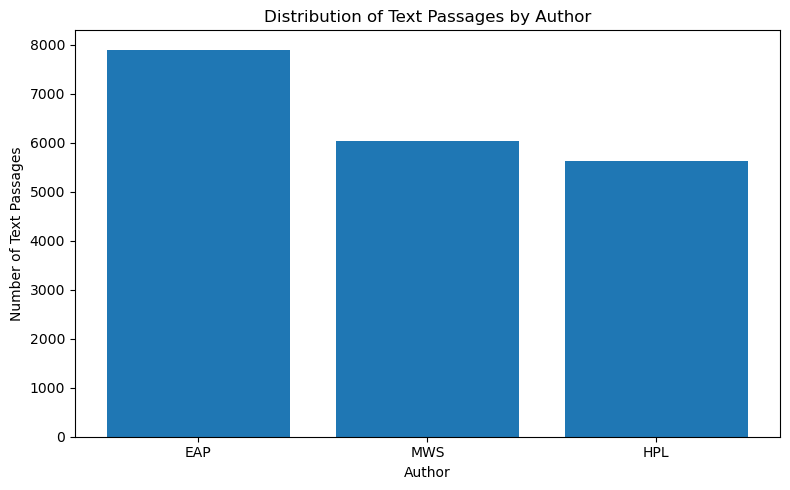

In [11]:
author_rows = author_counts.collect()

authors = [row["author"] for row in author_rows]
counts = [row["count"] for row in author_rows]

plt.figure(figsize=(8, 5))
plt.bar(authors, counts)

plt.xlabel("Author")
plt.ylabel("Number of Text Passages")
plt.title("Distribution of Text Passages by Author")

plt.tight_layout()
plt.show()

**2.3 Passage-Length Analysis**

Two additional variables are created for exploratory purposes: `character_count` and `word_count`.
Character count measures the number of characters contained in each passage, while word count provides an approximate measure of the number of words.
Examining passage length helps identify differences in the size of the text observations and provides useful information when selecting the maximum sequence length for the LSTM.

In [12]:
eda_df = (
    clean_df
    .withColumn("character_count", length(col("text")))
    .withColumn("word_count", size(split(trim(col("text")), r"\s+")))
)

eda_df.select(
    "author",
    "character_count",
    "word_count"
).show(10)

+------+---------------+----------+
|author|character_count|word_count|
+------+---------------+----------+
|   EAP|            109|        21|
|   HPL|             75|        15|
|   HPL|             88|        16|
|   EAP|            118|        19|
|   EAP|             61|        12|
|   EAP|             43|         8|
|   HPL|            211|        36|
|   EAP|            365|        60|
|   EAP|             70|        16|
|   EAP|            183|        35|
+------+---------------+----------+
only showing top 10 rows



**2.4 Passage-Length Summary Statistics**

Descriptive statistics are calculated for the character count and word count variables.
The minimum, maximum, mean and percentile values provide an overview of the typical size and variability of the text passages.
The results also help determine whether very short or very long passages are present and support the decision to standardise sequence length before training the neural network.

In [13]:
eda_df.select(
    "character_count",
    "word_count"
).summary().show()

+-------+------------------+------------------+
|summary|   character_count|        word_count|
+-------+------------------+------------------+
|  count|             19579|             19579|
|   mean|149.05740844782676|26.730476530977068|
| stddev|106.80018861273624|19.048353080110644|
|    min|                21|                 2|
|    25%|                81|                15|
|    50%|               128|                23|
|    75%|               191|                34|
|    max|              4663|               861|
+-------+------------------+------------------+



**2.6 Average Passage Length by Author**

The average word count and character count are calculated separately for each author.
This analysis determines whether the authors differ in the average length of their available passages. Differences in passage length may represent one aspect of writing style, although the LSTM will primarily learn from patterns within the actual word sequences.

Interpretation:

The results indicate that **HPL** has the longest passages on average, while **EAP** has the shortest passages on average.
This demonstrates that some differences in passage structure exist between the authors and may contribute to the patterns available to the classification model.

In [14]:
length_by_author = (
    eda_df
    .groupBy("author")
    .agg(
        avg("word_count").alias("average_words"),
        avg("character_count").alias("average_characters")
    )
    .orderBy(desc("average_words"))
)

length_by_author.show()

+------+------------------+------------------+
|author|     average_words|average_characters|
+------+------------------+------------------+
|   HPL|27.799645075421473|155.84347826086957|
|   MWS|27.417273328921244|151.65982792852415|
|   EAP| 25.44240506329114|142.22594936708862|
+------+------------------+------------------+



***3. FEATURE SELECTION AND DATA PREPARATION***

Convert cleaned data to Pandas

**3.1 Preparing the Data for Model Training**

Following the Spark-based exploratory analysis and cleaning process, the variables required for machine learning are selected.
Only `text` and `author` are transferred to a Pandas DataFrame. The `id` variable is excluded because it is an identifier and does not provide meaningful information about an author's writing style.
Spark has therefore been used for the data-processing and analytical stages, while Pandas and TensorFlow/Keras will now be used for neural network preparation and training.

In [15]:
model_pd = clean_df.select(
    "text",
    "author"
).toPandas()

print(model_pd.shape)
model_pd.head()

(19579, 2)


,text,author
0,The bandage lay heavily about the mouth but th...,EAP
1,We expelled the bodies through the double hatc...,HPL
2,"Of the various tales that of aged Soames, the ...",HPL
3,"Besides, the estates, which were contiguous, h...",EAP
4,"Its faces are large and white, and its hands h...",EAP


**Encode the author labels**

**3.2 Encoding the Target Variable**

The author names are categorical values, but the neural network requires numerical target labels.`LabelEncoder` is therefore used to assign a numerical class to each author. Each of the three authors receives a unique integer value.
The encoded author variable becomes the target variable that the LSTM will attempt to predict.

In [16]:
label_encoder = LabelEncoder()

model_pd["author_encoded"] = label_encoder.fit_transform(
    model_pd["author"]
)

print("Author classes:")

for i, author in enumerate(label_encoder.classes_):
    print(i, "=", author)

Author classes:
0 = EAP
1 = HPL
2 = MWS


**3.3 Training and Testing Split**

The dataset is divided into training and testing subsets.
Eighty percent of the observations are allocated to the training dataset, while 20% are reserved for testing. The training data is used to develop the model, while the test data remains unseen during training and is later used to measure generalisation performance.
Stratification is applied using the author labels to maintain approximately the same class proportions in the training and testing datasets.

In [17]:
X = model_pd["text"]
y = model_pd["author_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 15663
Testing samples: 3916


**3.5 Text Tokenisation**

Raw text cannot be supplied directly to the LSTM. The words must first be represented numerically.
A tokenizer is fitted using only the training text. It creates a vocabulary and assigns an integer index to each recognised word.
The vocabulary is limited to 15,000 words to control model complexity. An out-of-vocabulary token is also included so that words outside the selected vocabulary can still be represented.
The fitted tokenizer is then used to convert both the training and test passages into sequences of integers.

In [18]:
VOCAB_SIZE = 15000
MAX_LENGTH = 100

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

**3.6 Sequence Padding**

The tokenised passages contain different numbers of words and therefore produce sequences of different lengths.
The sequences are padded or truncated to a maximum length of 100 tokens. Short passages receive padding at the end, while passages longer than 100 tokens are truncated.
This creates consistently sized inputs that can be processed efficiently by the LSTM network.

In [21]:
X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (15663, 100)
Testing shape: (3916, 100)


**3.7 Baseline LSTM Model**

A baseline LSTM model is constructed to establish an initial performance benchmark.
The embedding layer converts word indices into dense numerical representations. The LSTM layer processes these embeddings sequentially and attempts to learn relationships between words and writing patterns.
Dropout is included to reduce overfitting by randomly excluding a proportion of neural connections during training. A dense hidden layer is used before the final output layer.
The output layer contains three neurons with a softmax activation function because the task involves predicting one of three author classes.
The model uses the Adam optimiser and sparse categorical cross-entropy loss, which is appropriate for multi-class classification with integer-encoded target labels.

In [22]:
NUM_CLASSES = len(label_encoder.classes_)

baseline_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64
    ),
    
    LSTM(64),
    
    Dropout(0.30),
    
    Dense(64, activation="relu"),
    
    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**3.8 Baseline Model Training**

The baseline model is trained using the prepared text sequences. Twenty percent of the training data is used internally for validation.
The model is trained for a maximum of 10 epochs using a batch size of 64. Validation performance is recorded during each epoch so that the model's ability to generalise can be compared with its performance on the training data.

In [23]:
baseline_history = baseline_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.4019 - loss: 1.0899 - val_accuracy: 0.4057 - val_loss: 1.0872
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.4030 - loss: 1.0887 - val_accuracy: 0.4057 - val_loss: 1.0873
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.4030 - loss: 1.0885 - val_accuracy: 0.4057 - val_loss: 1.0871
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.4030 - loss: 1.0880 - val_accuracy: 0.4057 - val_loss: 1.0871
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.4044 - loss: 1.0873 - val_accuracy: 0.4063 - val_loss: 1.0870
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.4043 - loss: 1.0927 - val_accuracy: 0.4057 - val_loss: 1.0874
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.4044 - loss: 1.0876 - val_accuracy: 0.4060 - val_loss: 1.0868
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.4045 - loss: 1.0865 - 

**3.9 Baseline Training and Validation Accuracy***

Training and validation accuracy are plotted across the training epochs.
This visualisation helps determine whether the model is learning useful patterns and whether its performance generalises beyond the training data.
If training accuracy continues increasing while validation accuracy stops improving or decreases, this may indicate overfitting.

Interpretation:

The graph shows that both training and validation accuracy remained relatively stable at around 40% throughout the 10 epochs. Validation accuracy was consistently slightly higher than training accuracy, but neither improved substantially. This suggests that the baseline LSTM is underfitting and is not learning enough useful patterns from the text to effectively distinguish between the authors. The model should therefore be improved by adjusting its architecture and hyperparameters.

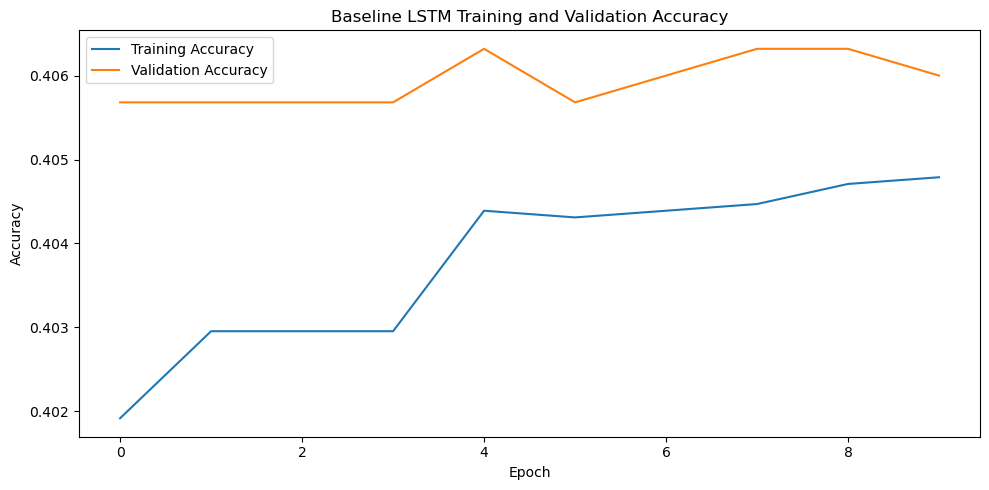

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline LSTM Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**3.10 Baseline Training and Validation Loss**

Training and validation loss are plotted across the training epochs.
Loss measures the magnitude of the model's classification error. Ideally, both training and validation loss should decrease as the model learns.
If training loss continues decreasing while validation loss begins increasing, the model may be learning the training data too specifically and therefore overfitting.

Interpretation:

The training and validation loss remain relatively stable, with only a small overall decrease across the epochs. The training loss drops from approximately 1.090 to 1.083, while validation loss remains around 1.086–1.087. Together with the low accuracy observed in Cell 25, this indicates that the baseline LSTM is underfitting and has not learned strong enough patterns to reliably distinguish between the three authors.

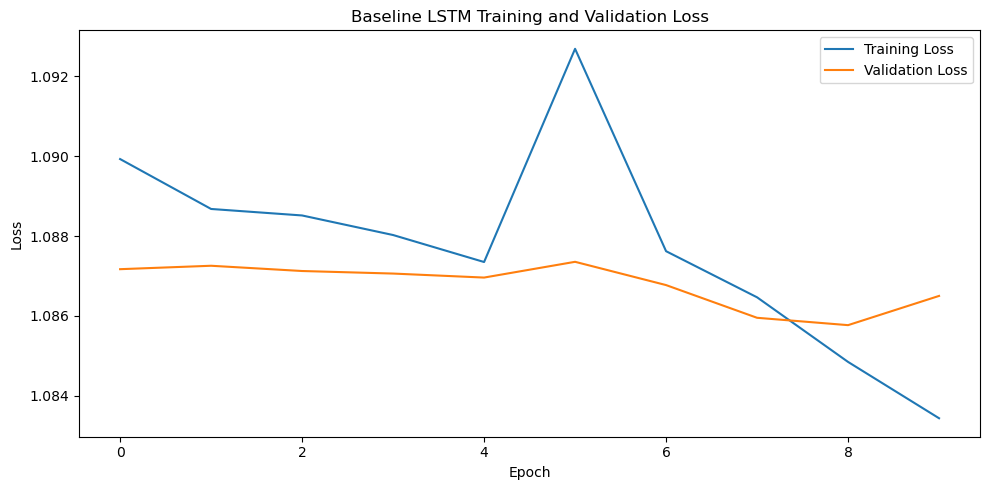

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline LSTM Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

***4. MODEL EVALUATION***

**4.1 Baseline Test Performance**

The baseline model is evaluated using the unseen test dataset.
Testing on observations that were not used during model training provides a more reliable indication of how well the model is likely to perform when presented with new text passages.
Both test loss and test accuracy are calculated.


The baseline LSTM achieved a test accuracy of **0.40372830629348755** and a test loss of **1.0875117778778076**.    

In [26]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_accuracy)

Baseline Test Loss: 1.0875117778778076
Baseline Test Accuracy: 0.40372830629348755


**4.2 Generating Baseline Predictions**

The baseline model generates probability estimates for each of the three possible author classes.
For each test passage, the class with the highest predicted probability is selected as the final predicted author.
These predictions are compared with the actual author labels to calculate additional classification metrics.

In [27]:
baseline_prob = baseline_model.predict(
    X_test_pad,
    verbose=0
)

baseline_pred = np.argmax(
    baseline_prob,
    axis=1
)

**4.3 Baseline Performance Metrics**

Accuracy, precision, recall and F1-score are calculated to provide a comprehensive evaluation of the baseline model.

**Accuracy** represents the overall proportion of passages classified correctly.
**Precision** measures how frequently predictions assigned to an author are correct.
**Recall** measures the model's ability to identify passages that genuinely belong to each author.
**F1-score** provides a balance between precision and recall and is useful for assessing overall classification quality.
Using several metrics provides a more complete assessment than relying on accuracy alone.

Baseline Results:

The baseline model achieved:

Accuracy: 0.40372830629348755
Precision: 0.33919135899871794
Recall: 0.40372829417773237
F1-score: 0.2338682014928391

These results provide the benchmark against which the improved LSTM will be evaluated.    

In [28]:
baseline_precision = precision_score(
    y_test,
    baseline_pred,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

Accuracy: 0.40372830629348755
Precision: 0.33919135899871794
Recall: 0.40372829417773237
F1-score: 0.2338682014928391


**4.4 Classification Report**

The classification report provides precision, recall and F1-score separately for each author.
Class-specific evaluation is important because overall accuracy may hide differences in how successfully the model identifies individual authors.
The report therefore helps determine whether the model performs consistently across all three author classes.

Interpretation:

The classification report shows that **EAP** achieved the strongest classification performance, while **HPL** was more difficult for the model to classify correctly.
This indicates that some author writing styles may contain more distinctive patterns than others.    

In [29]:
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         EAP       0.40      1.00      0.57      1580
         HPL       0.00      0.00      0.00      1127
         MWS       0.57      0.00      0.01      1209

    accuracy                           0.40      3916
   macro avg       0.32      0.33      0.19      3916
weighted avg       0.34      0.40      0.23      3916



**4.5 Baseline Confusion Matrix**

A confusion matrix is generated to compare the actual author labels with the authors predicted by the baseline model.
Values along the main diagonal represent passages that were classified correctly. Values outside the diagonal represent incorrect classifications.
The confusion matrix is useful for identifying which author pairs are most frequently confused by the model.

Interpretation:

The confusion matrix shows that the baseline LSTM predicts almost every passage as EAP (Edgar Allan Poe). It correctly classified 1,577 EAP passages, but incorrectly classified 1,127 HPL passages and 1,205 MWS passages as EAP. The model made virtually no correct predictions for HPL and only 4 correct predictions for MWS. This confirms that the baseline model performs poorly across the three authors and supports the need to retrain and improve the model.    

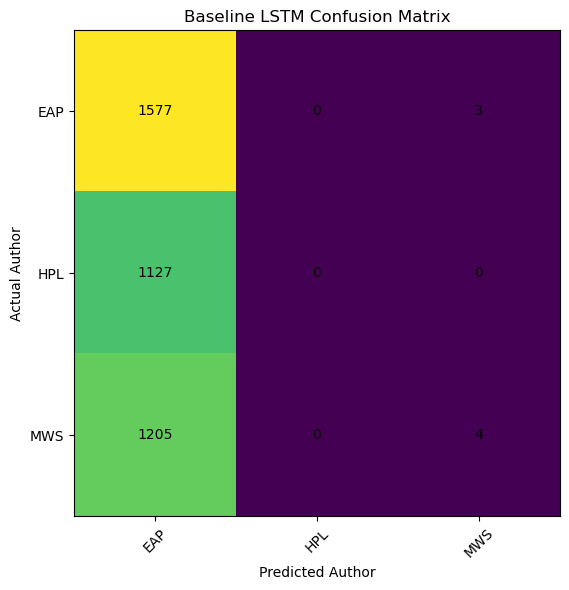

In [30]:
cm = confusion_matrix(
    y_test,
    baseline_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Author")
plt.ylabel("Actual Author")
plt.title("Baseline LSTM Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Evaluation Metric Justification

Accuracy is used to measure overall classification performance. However, accuracy alone is not sufficient because it does not show how the model performs for individual authors.

Precision and recall are therefore included to assess the reliability of predictions and the model's ability to identify each class. F1-score combines precision and recall and provides an additional measure of balanced classification performance.

The classification report provides class-specific results, while the confusion matrix identifies the particular authors that are incorrectly classified.

Training and validation accuracy and loss are also considered because they help identify overfitting and underfitting.

Together, these evaluation methods provide a comprehensive assessment of the LSTM model's effectiveness.

**4.7 Improved LSTM Model**

A second model is developed to determine whether the performance of the baseline LSTM can be improved.
Several changes are introduced to the architecture. The embedding dimension is increased from 64 to 128 to provide richer word representations. A bidirectional LSTM is introduced to learn sequential relationships in both directions.
Additional LSTM capacity is included and dropout is increased to reduce the risk of overfitting. The learning rate is reduced from 0.001 to 0.0005 so that the model can update its weights more gradually.
These modifications aim to improve the model's ability to recognise complex writing patterns while maintaining good generalisation performance.

In [31]:
improved_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    Bidirectional(
        LSTM(
            96,
            return_sequences=True
        )
    ),

    Dropout(0.40),

    LSTM(64),

    Dropout(0.40),

    Dense(64, activation="relu"),

    Dropout(0.30),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**4.8 Early Stopping**

Early stopping is introduced to reduce unnecessary training and help prevent overfitting.
Validation loss is monitored during model training. If validation loss does not improve for three consecutive epochs, training is automatically stopped.
The `restore_best_weights` option ensures that the model returns to the weights obtained during the epoch with the best validation performance rather than retaining weights from a later, potentially overfitted epoch.

In [32]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

**4.9 Training the Improved Model**

The improved model is trained using the same training data as the baseline model to ensure a fair comparison.
The model is allowed to train for a maximum of 15 epochs using a batch size of 64. Early stopping may terminate training before all 15 epochs are completed if validation loss stops improving.
The validation results are monitored throughout training to determine whether the revised architecture improves generalisation.

In [33]:
improved_history = improved_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 205s 930ms/step - accuracy: 0.3982 - loss: 1.0910 - val_accuracy: 0.4057 - val_loss: 1.0869
Epoch 2/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 169s 861ms/step - accuracy: 0.4030 - loss: 1.0894 - val_accuracy: 0.4057 - val_loss: 1.0866
Epoch 3/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 133s 677ms/step - accuracy: 0.4030 - loss: 1.0892 - val_accuracy: 0.4057 - val_loss: 1.0870
Epoch 4/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 156s 798ms/step - accuracy: 0.4022 - loss: 1.0889 - val_accuracy: 0.4057 - val_loss: 1.0867
Epoch 5/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 159s 810ms/step - accuracy: 0.4030 - loss: 1.0883 - val_accuracy: 0.4057 - val_loss: 1.0866


**4.10 Improved Model Test Performance**

The improved LSTM is evaluated using the same unseen test dataset used to evaluate the baseline model.
Using the same test observations allows the performance of the two models to be compared fairly.
Test accuracy and test loss are calculated to determine whether the architectural and hyperparameter changes resulted in improved performance.

The improved model achieved a test accuracy of **0.4034729301929474** and a test loss of **1.0876072645187378**.    

In [34]:
improved_loss, improved_accuracy = improved_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Improved Test Loss:", improved_loss)
print("Improved Test Accuracy:", improved_accuracy)

Improved Test Loss: 1.0876072645187378
Improved Test Accuracy: 0.4034729301929474


**4.11 Improved Model Predictions**

The improved model generates probability estimates for each author for every passage in the test dataset.
The author associated with the highest probability is selected as the final predicted class.
These predictions are used to calculate the improved model's precision, recall and F1-score.

In [35]:
improved_prob = improved_model.predict(
    X_test_pad,
    verbose=0
)

improved_pred = np.argmax(
    improved_prob,
    axis=1
)

**4.12 Improved Model Performance Metrics**

The improved model is evaluated using the same performance measures as the baseline model.

Using identical metrics ensures that the two models can be compared consistently and helps determine whether the modifications produced a meaningful improvement.

The improved model achieved:

Improved Accuracy: 0.4034729301929474
Improved Precision: 0.1627904065038954
Improved Recall: 0.4034729315628192
Improved F1-score: 0.2319822532275307

These values will now be compared directly with the baseline model.

In [36]:
improved_precision = precision_score(
    y_test,
    improved_pred,
    average="weighted",
    zero_division=0
)

improved_recall = recall_score(
    y_test,
    improved_pred,
    average="weighted",
    zero_division=0
)

improved_f1 = f1_score(
    y_test,
    improved_pred,
    average="weighted",
    zero_division=0
)

print("Improved Accuracy:", improved_accuracy)
print("Improved Precision:", improved_precision)
print("Improved Recall:", improved_recall)
print("Improved F1-score:", improved_f1)

Improved Accuracy: 0.4034729301929474
Improved Precision: 0.1627904065038954
Improved Recall: 0.4034729315628192
Improved F1-score: 0.2319822532275307


**4.13 Baseline and Improved Model Comparison**

The baseline and improved LSTM models are compared using accuracy, precision, recall and F1-score.
The purpose of this comparison is to determine whether changes to the embedding dimension, LSTM architecture, dropout and learning rate improved classification performance.
The model that performs better on the unseen test dataset will be selected as the final model because test performance provides a better indication of generalisation than training accuracy.

The improved LSTM did not meaningfully improve the model's performance. Accuracy remained almost unchanged at approximately 40.35%, while precision decreased from 33.92% to 16.28% and the F1-score decreased slightly from 23.39% to 23.20%. Recall remained almost identical at approximately 40.35%. These results indicate that the changes made to the LSTM architecture and hyperparameters did not resolve the model's poor classification performance, and further improvements to text preprocessing, class handling, and model configuration would be required.

In [37]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    
    "Baseline LSTM": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    
    "Improved LSTM": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1
    ]
})

comparison

,Metric,Baseline LSTM,Improved LSTM
0,Accuracy,0.403728,0.403473
1,Precision,0.339191,0.162790
2,Recall,0.403728,0.403473
3,F1-score,0.233868,0.231982


***Conclusion***

The objective of this analysis was to develop an LSTM-based classification model capable of identifying an author from writing style.

Apache Spark was used for data loading, cleaning and exploratory analysis. The dataset was examined for missing values, duplicates, class distribution and text length before model development.

The text was converted into numerical sequences using tokenisation and padding. A baseline LSTM was trained and evaluated using accuracy, precision, recall, F1-score and a confusion matrix.

An improved model was subsequently developed using a larger embedding layer, bidirectional LSTM processing, additional dropout and a reduced learning rate.

The final model should be selected based on its performance on the unseen test dataset rather than training accuracy alone.

The findings demonstrate that recurrent neural networks can learn patterns in writing style and can be applied to multi-class author identification.